# **Modelling Random Forest**

In [1]:
import os
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')

import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='Set2')

In [ ]:
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == 'notebooks' else CURRENT_DIR
DATA_PATH = PROJECT_ROOT / 'data' / 'final for modelling' / 'dataset_final_model.csv'
OUTPUT_DIR = PROJECT_ROOT / 'notebooks' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f': {DATA_PATH}')

df_raw = pd.read_csv(DATA_PATH, parse_dates=['tanggal'])

print('Path dataset:', DATA_PATH)
print('Shape dataset:', df_raw.shape)
display(df_raw.head())

Path dataset: c:\Users\User\Air Pollution - Daming Project\data\final for modelling\dataset_final_model.csv
Shape dataset: (7679, 18)


,tanggal,ISPU PM2.5,kategori_pm25,bulan,hari_minggu,temp,humidity,visibility,windgust,solarenergy,precip,station_bundaran hi,station_jagakarsa,station_kebun jeruk,station_kelapa gading,station_lubang buaya,station_us embassy 1,station_us embassy 2
0,2022-01-01,74.000000,Sedang,1,5,28.6,77.2,6.7,37.1,20.6,0.496,1,0,0,0,0,0,0
1,2022-01-01,73.000000,Sedang,1,5,28.3,77.8,6.8,37.1,20.6,0.502,0,1,0,0,0,0,0
2,2022-01-01,71.000000,Sedang,1,5,28.3,79.3,7.5,37.1,20.6,0.645,0,0,1,0,0,0,0
3,2022-01-01,74.973893,Sedang,1,5,28.6,76.9,6.7,34.9,21.0,0.262,0,0,0,1,0,0,0
4,2022-01-01,80.000000,Sedang,1,5,28.5,76.8,6.2,34.9,21.0,0.451,0,0,0,0,1,0,0


# Check Data Modelling

In [3]:
print('Informasi kolom dan tipe data:')
display(df_raw.dtypes.to_frame('dtype'))

print('\nMissing value per kolom:')
display(df_raw.isna().sum().to_frame('missing'))

print('\nRange tanggal:', df_raw['tanggal'].min().date(), 'sampai', df_raw['tanggal'].max().date())
print('Jumlah tanggal unik:', df_raw['tanggal'].nunique())

print('\nStatistik target ISPU PM2.5:')
display(df_raw['ISPU PM2.5'].describe().to_frame('nilai'))

print('\nDistribusi kategori PM2.5:')
display(df_raw['kategori_pm25'].value_counts().to_frame('jumlah'))

Informasi kolom dan tipe data:


,dtype
tanggal,datetime64[us]
ISPU PM2.5,float64
kategori_pm25,str
bulan,int64
hari_minggu,int64
temp,float64
humidity,float64
visibility,float64
windgust,float64
solarenergy,float64



Missing value per kolom:


,missing
tanggal,0
ISPU PM2.5,0
kategori_pm25,0
bulan,0
hari_minggu,0
temp,7
humidity,7
visibility,7
windgust,7
solarenergy,7



Range tanggal: 2022-01-01 sampai 2025-01-01
Jumlah tanggal unik: 1097

Statistik target ISPU PM2.5:


,nilai
count,7679.000000
mean,71.570914
std,21.094232
min,0.000000
25%,59.307991
50%,73.652589
75%,85.457653
max,190.473729



Distribusi kategori PM2.5:


,jumlah
kategori_pm25,
Sedang,6082
Baik,1083
Tidak Sehat,514


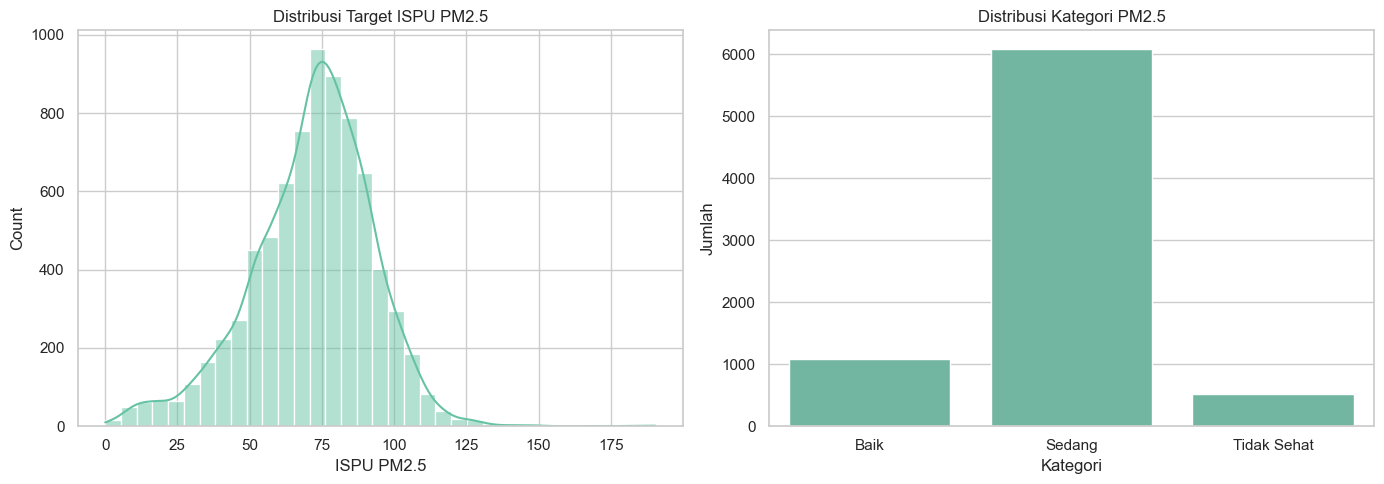

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_raw['ISPU PM2.5'], bins=35, kde=True, ax=axes[0])
axes[0].set_title('Distribusi Target ISPU PM2.5')
axes[0].set_xlabel('ISPU PM2.5')

sns.countplot(data=df_raw, x='kategori_pm25', order=['Baik', 'Sedang', 'Tidak Sehat'], ax=axes[1])
axes[1].set_title('Distribusi Kategori PM2.5')
axes[1].set_xlabel('Kategori')
axes[1].set_ylabel('Jumlah')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribusi_target_pm25_modelling.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Engineering

In [ ]:
def get_station_name(df):
    station_cols = [col for col in df.columns if col.startswith('station_')]
    if not station_cols:
        raise ValueError('Kolom station_ ga ada (station di-one-hot encoding dulu)')
    return df[station_cols].idxmax(axis=1).str.replace('station_', '', regex=False)


def add_modelling_features(df):
    df_feat = df.copy()
    df_feat['tanggal'] = pd.to_datetime(df_feat['tanggal'])
    df_feat['station'] = get_station_name(df_feat)
    df_feat = df_feat.sort_values(['station', 'tanggal']).reset_index(drop=True)

    # Fitur siklus waktu
    df_feat['bulan_sin'] = np.sin(2 * np.pi * df_feat['bulan'] / 12)
    df_feat['bulan_cos'] = np.cos(2 * np.pi * df_feat['bulan'] / 12)
    df_feat['hari_minggu_sin'] = np.sin(2 * np.pi * df_feat['hari_minggu'] / 7)
    df_feat['hari_minggu_cos'] = np.cos(2 * np.pi * df_feat['hari_minggu'] / 7)

    # Fitur historis PM2.5 per station. Shift(1) untuk menghindari target leakage
    for lag in [1, 2, 7, 14]:
        df_feat[f'pm25_lag_{lag}'] = df_feat.groupby('station')['ISPU PM2.5'].shift(lag)

    shifted_pm25 = df_feat.groupby('station')['ISPU PM2.5'].shift(1)
    for window in [3, 7, 14]:
        grouped_shifted = shifted_pm25.groupby(df_feat['station'])
        df_feat[f'pm25_roll_{window}_mean'] = grouped_shifted.rolling(window).mean().reset_index(level=0, drop=True)
        df_feat[f'pm25_roll_{window}_std'] = grouped_shifted.rolling(window).std().reset_index(level=0, drop=True)

    df_feat = df_feat.sort_values(['tanggal', 'station']).reset_index(drop=True)
    return df_feat


df_model = add_modelling_features(df_raw)

TARGET_REG = 'ISPU PM2.5'
TARGET_CAT = 'kategori_pm25'
DROP_COLS = ['tanggal', TARGET_REG, TARGET_CAT, 'station']
FEATURES = [col for col in df_model.columns if col not in DROP_COLS]

print('Shape setelah feature engineering:', df_model.shape)
print('Jumlah fitur modelling:', len(FEATURES))
print('\nContoh fitur historis:')
display(df_model[['tanggal', 'station', TARGET_REG, 'pm25_lag_1', 'pm25_lag_7', 'pm25_roll_7_mean']].head(20))

Shape setelah feature engineering: (7679, 33)
Jumlah fitur modelling: 29

Contoh fitur historis:


,tanggal,station,ISPU PM2.5,pm25_lag_1,pm25_lag_7,pm25_roll_7_mean
0,2022-01-01,bundaran hi,74.000000,NaN,NaN,NaN
1,2022-01-01,jagakarsa,73.000000,NaN,NaN,NaN
2,2022-01-01,kebun jeruk,71.000000,NaN,NaN,NaN
3,2022-01-01,kelapa gading,74.973893,NaN,NaN,NaN
4,2022-01-01,lubang buaya,80.000000,NaN,NaN,NaN
5,2022-01-01,us embassy 1,70.284673,NaN,NaN,NaN
6,2022-01-01,us embassy 2,77.250157,NaN,NaN,NaN
7,2022-01-02,bundaran hi,74.000000,74.000000,NaN,NaN
8,2022-01-02,jagakarsa,73.000000,73.000000,NaN,NaN
9,2022-01-02,kebun jeruk,71.000000,71.000000,NaN,NaN


In [21]:
print('Check fitur yang digunakan model:')
print(FEATURES)

print('\nJumlah missing value pada fitur hasil engineering:')
missing_features = df_model[FEATURES].isna().sum()
display(missing_features[missing_features > 0].to_frame('missing'))

print('\nTarget masuk fitur', TARGET_REG in FEATURES)
print('Kategori target masuk fitur', TARGET_CAT in FEATURES)

Check fitur yang digunakan model:
['bulan', 'hari_minggu', 'temp', 'humidity', 'visibility', 'windgust', 'solarenergy', 'precip', 'station_bundaran hi', 'station_jagakarsa', 'station_kebun jeruk', 'station_kelapa gading', 'station_lubang buaya', 'station_us embassy 1', 'station_us embassy 2', 'bulan_sin', 'bulan_cos', 'hari_minggu_sin', 'hari_minggu_cos', 'pm25_lag_1', 'pm25_lag_2', 'pm25_lag_7', 'pm25_lag_14', 'pm25_roll_3_mean', 'pm25_roll_3_std', 'pm25_roll_7_mean', 'pm25_roll_7_std', 'pm25_roll_14_mean', 'pm25_roll_14_std']

Jumlah missing value pada fitur hasil engineering:


,missing
temp,7
humidity,7
visibility,7
windgust,7
solarenergy,7
precip,7
pm25_lag_1,7
pm25_lag_2,14
pm25_lag_7,49
pm25_lag_14,98



Target masuk fitur False
Kategori target masuk fitur False


## Split Train, Validation, dan Test (time based) 

In [7]:
def make_time_split(df, date_col='tanggal', test_size=0.20, validation_size_from_train=0.15):
    unique_dates = np.array(sorted(df[date_col].unique()))

    test_start_idx = int(len(unique_dates) * (1 - test_size))
    test_start = pd.Timestamp(unique_dates[test_start_idx])

    train_val_dates = unique_dates[:test_start_idx]
    validation_start_idx = int(len(train_val_dates) * (1 - validation_size_from_train))
    validation_start = pd.Timestamp(train_val_dates[validation_start_idx])

    train_core_mask = df[date_col] < validation_start
    validation_mask = (df[date_col] >= validation_start) & (df[date_col] < test_start)
    train_full_mask = df[date_col] < test_start
    test_mask = df[date_col] >= test_start

    return train_core_mask, validation_mask, train_full_mask, test_mask, validation_start, test_start


train_core_mask, validation_mask, train_full_mask, test_mask, validation_start, test_start = make_time_split(df_model)

X_train_core = df_model.loc[train_core_mask, FEATURES]
y_train_core = df_model.loc[train_core_mask, TARGET_REG]

X_validation = df_model.loc[validation_mask, FEATURES]
y_validation = df_model.loc[validation_mask, TARGET_REG]

X_train_full = df_model.loc[train_full_mask, FEATURES]
y_train_full = df_model.loc[train_full_mask, TARGET_REG]

X_test = df_model.loc[test_mask, FEATURES]
y_test = df_model.loc[test_mask, TARGET_REG]

print('Validation mulai:', validation_start.date())
print('Test mulai      :', test_start.date())
print('\nTrain core:', X_train_core.shape, df_model.loc[train_core_mask, 'tanggal'].min().date(), 'sampai', df_model.loc[train_core_mask, 'tanggal'].max().date())
print('Validation:', X_validation.shape, df_model.loc[validation_mask, 'tanggal'].min().date(), 'sampai', df_model.loc[validation_mask, 'tanggal'].max().date())
print('Train full:', X_train_full.shape, df_model.loc[train_full_mask, 'tanggal'].min().date(), 'sampai', df_model.loc[train_full_mask, 'tanggal'].max().date())
print('Test      :', X_test.shape, df_model.loc[test_mask, 'tanggal'].min().date(), 'sampai', df_model.loc[test_mask, 'tanggal'].max().date())

Validation mulai: 2024-01-16
Test mulai      : 2024-05-27

Train core: (5215, 29) 2022-01-01 sampai 2024-01-15
Validation: (924, 29) 2024-01-16 sampai 2024-05-26
Train full: (6139, 29) 2022-01-01 sampai 2024-05-26
Test      : (1540, 29) 2024-05-27 sampai 2025-01-01


## Fungsi Evaluasi

In [8]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2': r2_score(y_true, y_pred),
    }


def kategori_pm25(value):
    if value <= 50:
        return 'Baik'
    if value <= 100:
        return 'Sedang'
    return 'Tidak Sehat'


def category_metrics(y_true_pm25_category, y_pred_pm25_value):
    y_pred_category = pd.Series(y_pred_pm25_value).map(kategori_pm25)
    return {
        'accuracy': accuracy_score(y_true_pm25_category, y_pred_category),
        'macro_f1': f1_score(y_true_pm25_category, y_pred_category, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true_pm25_category, y_pred_category, average='weighted', zero_division=0),
    }


def make_rf_pipeline(**rf_params):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1, **rf_params)),
    ])


def display_metrics(title, metrics):
    print(title)
    for key, value in metrics.items():
        print(f'{key}: {value:.4f}')

## Baseline Model

In [9]:
baseline_rows = []

baseline_mean = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', DummyRegressor(strategy='mean')),
])
baseline_mean.fit(X_train_full, y_train_full)
baseline_mean_pred = baseline_mean.predict(X_test)
baseline_rows.append({'model': 'Baseline Mean', **regression_metrics(y_test, baseline_mean_pred)})

baseline_lag1_pred = X_test['pm25_lag_1'].fillna(y_train_full.mean())
baseline_rows.append({'model': 'Baseline Lag-1', **regression_metrics(y_test, baseline_lag1_pred)})

baseline_df = pd.DataFrame(baseline_rows).sort_values('RMSE').reset_index(drop=True)
baseline_df[['MAE', 'RMSE', 'R2']] = baseline_df[['MAE', 'RMSE', 'R2']].round(4)
display(baseline_df)

,model,MAE,RMSE,R2
0,Baseline Lag-1,10.2263,14.0955,0.5360
1,Baseline Mean,17.2222,21.2096,-0.0507


## Random Forest Regression (1)

In [10]:
rf_default = make_rf_pipeline(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=1,
    max_features=1.0,
)

rf_default.fit(X_train_full, y_train_full)
rf_default_pred = rf_default.predict(X_test)
rf_default_metrics = regression_metrics(y_test, rf_default_pred)

display_metrics('Evaluasi Random Forest awal pada test set:', rf_default_metrics)

Evaluasi Random Forest awal pada test set:
MAE: 8.8936
RMSE: 12.2501
R2: 0.6495


## Hyperparameter Tuning Random Forest

In [11]:
rf_tuning_configs = [
    {'config': 'RF_default_leaf2', 'n_estimators': 120, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 0.8},
    {'config': 'RF_deeper_leaf1', 'n_estimators': 120, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 0.8},
    {'config': 'RF_robust_leaf4', 'n_estimators': 120, 'max_depth': None, 'min_samples_leaf': 4, 'max_features': 0.8},
    {'config': 'RF_depth16_leaf2', 'n_estimators': 120, 'max_depth': 16, 'min_samples_leaf': 2, 'max_features': 0.8},
    {'config': 'RF_sqrt_leaf2', 'n_estimators': 120, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 'sqrt'},
    {'config': 'RF_wide_leaf2', 'n_estimators': 120, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 1.0},
]

tuning_rows = []

for config in rf_tuning_configs:
    config_name = config['config']
    params = {key: value for key, value in config.items() if key != 'config'}

    model = make_rf_pipeline(**params)
    model.fit(X_train_core, y_train_core)
    validation_pred = model.predict(X_validation)
    metrics = regression_metrics(y_validation, validation_pred)

    tuning_rows.append({'config': config_name, **params, **metrics})

rf_tuning_df = pd.DataFrame(tuning_rows).sort_values('RMSE').reset_index(drop=True)
rf_tuning_display = rf_tuning_df.copy()
rf_tuning_display[['MAE', 'RMSE', 'R2']] = rf_tuning_display[['MAE', 'RMSE', 'R2']].round(4)

display(rf_tuning_display)
rf_tuning_display.to_csv(OUTPUT_DIR / 'hasil_tuning_random_forest.csv', index=False)

best_tuning_row = rf_tuning_df.iloc[0].to_dict()
best_rf_params = {
    'n_estimators': 300,
    'max_depth': best_tuning_row['max_depth'] if not pd.isna(best_tuning_row['max_depth']) else None,
    'min_samples_leaf': int(best_tuning_row['min_samples_leaf']),
    'max_features': best_tuning_row['max_features'],
    'oob_score': True,
}

print('Konfigurasi terbaik dari validation:', best_tuning_row['config'])
print('Parameter final Random Forest:', best_rf_params)

,config,n_estimators,max_depth,min_samples_leaf,max_features,MAE,RMSE,R2
0,RF_default_leaf2,120,NaN,2,0.8,9.0416,11.6249,0.6268
1,RF_depth16_leaf2,120,16.0,2,0.8,9.0989,11.6794,0.6233
2,RF_sqrt_leaf2,120,NaN,2,sqrt,9.1642,11.6943,0.6223
3,RF_wide_leaf2,120,NaN,2,1.0,9.1579,11.6956,0.6222
4,RF_deeper_leaf1,120,NaN,1,0.8,9.1764,11.7368,0.6195
5,RF_robust_leaf4,120,NaN,4,0.8,9.1787,11.7874,0.6163


Konfigurasi terbaik dari validation: RF_default_leaf2
Parameter final Random Forest: {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 0.8, 'oob_score': True}


## Training Random Forest Regression

In [12]:
rf_tuned = make_rf_pipeline(**best_rf_params)
rf_tuned.fit(X_train_full, y_train_full)
rf_tuned_pred = rf_tuned.predict(X_test)
rf_tuned_metrics = regression_metrics(y_test, rf_tuned_pred)

oob_score = rf_tuned.named_steps['model'].oob_score_
print('OOB R2 score Random Forest:', round(oob_score, 4))
display_metrics('Evaluasi Random Forest tuned pada test set:', rf_tuned_metrics)

comparison_rows = baseline_rows + [
    {'model': 'Random Forest Awal', **rf_default_metrics},
    {'model': 'Random Forest Tuned', **rf_tuned_metrics},
]

hasil_model = pd.DataFrame(comparison_rows).sort_values('RMSE').reset_index(drop=True)
hasil_model[['MAE', 'RMSE', 'R2']] = hasil_model[['MAE', 'RMSE', 'R2']].round(4)

display(hasil_model)
hasil_model.to_csv(OUTPUT_DIR / 'hasil_model_regresi.csv', index=False)

OOB R2 score Random Forest: 0.7053
Evaluasi Random Forest tuned pada test set:
MAE: 8.8304
RMSE: 12.1527
R2: 0.6551


,model,MAE,RMSE,R2
0,Random Forest Tuned,8.8304,12.1527,0.6551
1,Random Forest Awal,8.8936,12.2501,0.6495
2,Baseline Lag-1,10.2263,14.0955,0.5360
3,Baseline Mean,17.2222,21.2096,-0.0507


## Evaluasi Prediksi Test Set

In [13]:
prediksi_test = df_model.loc[test_mask, ['tanggal', 'station', TARGET_REG, TARGET_CAT]].copy()
prediksi_test['prediksi_pm25'] = rf_tuned_pred
prediksi_test['residual'] = prediksi_test[TARGET_REG] - prediksi_test['prediksi_pm25']
prediksi_test['abs_error'] = prediksi_test['residual'].abs()
prediksi_test['kategori_prediksi'] = prediksi_test['prediksi_pm25'].map(kategori_pm25)

category_eval = category_metrics(prediksi_test[TARGET_CAT], prediksi_test['prediksi_pm25'])

print('Metrik regresi Random Forest tuned:')
for metric_name, metric_value in rf_tuned_metrics.items():
    print(f'{metric_name}: {metric_value:.4f}')

print('\nEvaluasi kategori dari prediksi PM2.5:')
for metric_name, metric_value in category_eval.items():
    print(f'{metric_name}: {metric_value:.4f}')

print('\nClassification report kategori:')
print(classification_report(prediksi_test[TARGET_CAT], prediksi_test['kategori_prediksi'], zero_division=0))

display(prediksi_test.head())
prediksi_test.to_csv(OUTPUT_DIR / 'prediksi_test_pm25.csv', index=False)

Metrik regresi Random Forest tuned:
MAE: 8.8304
RMSE: 12.1527
R2: 0.6551

Evaluasi kategori dari prediksi PM2.5:
accuracy: 0.8610
macro_f1: 0.5726
weighted_f1: 0.8294

Classification report kategori:
              precision    recall  f1-score   support

        Baik       0.80      0.68      0.74       190
      Sedang       0.87      0.97      0.92      1231
 Tidak Sehat       0.36      0.03      0.06       119

    accuracy                           0.86      1540
   macro avg       0.68      0.56      0.57      1540
weighted avg       0.82      0.86      0.83      1540



,tanggal,station,ISPU PM2.5,kategori_pm25,prediksi_pm25,residual,abs_error,kategori_prediksi
6139,2024-05-27,bundaran hi,91.598140,Sedang,79.591417,12.006722,12.006722,Sedang
6140,2024-05-27,jagakarsa,75.034239,Sedang,75.795167,-0.760928,0.760928,Sedang
6141,2024-05-27,kebun jeruk,92.237617,Sedang,82.408225,9.829391,9.829391,Sedang
6142,2024-05-27,kelapa gading,93.163690,Sedang,80.335395,12.828295,12.828295,Sedang
6143,2024-05-27,lubang buaya,77.476643,Sedang,81.583945,-4.107302,4.107302,Sedang


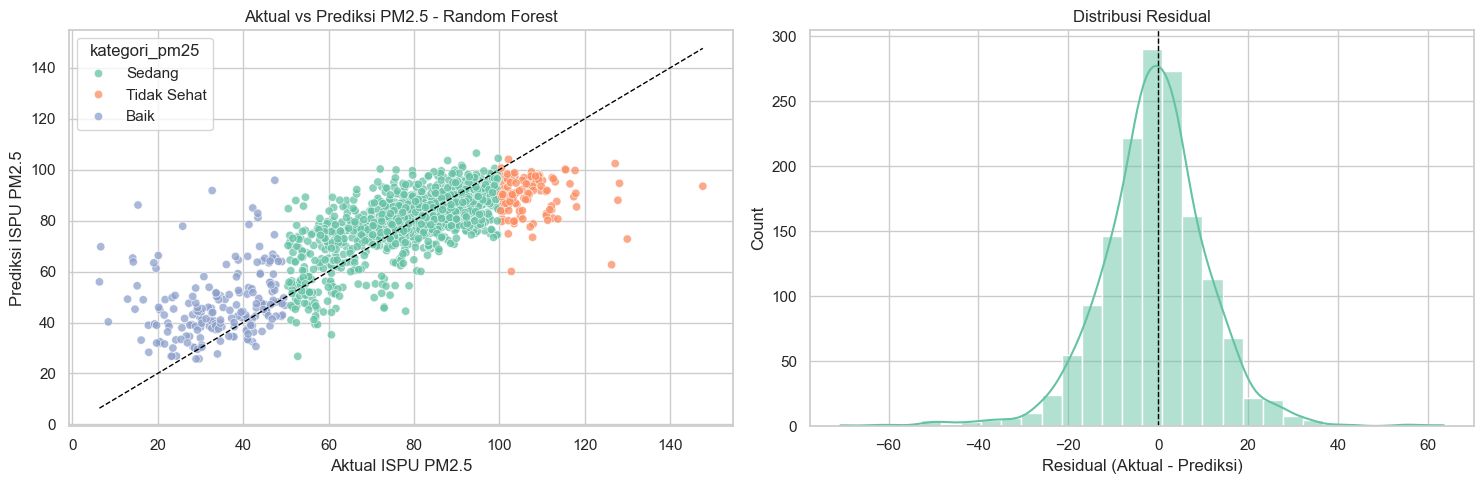

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    data=prediksi_test,
    x=TARGET_REG,
    y='prediksi_pm25',
    hue=TARGET_CAT,
    alpha=0.75,
    ax=axes[0],
)
min_val = min(prediksi_test[TARGET_REG].min(), prediksi_test['prediksi_pm25'].min())
max_val = max(prediksi_test[TARGET_REG].max(), prediksi_test['prediksi_pm25'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=1)
axes[0].set_title('Aktual vs Prediksi PM2.5 - Random Forest')
axes[0].set_xlabel('Aktual ISPU PM2.5')
axes[0].set_ylabel('Prediksi ISPU PM2.5')

sns.histplot(prediksi_test['residual'], kde=True, bins=30, ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Distribusi Residual')
axes[1].set_xlabel('Residual (Aktual - Prediksi)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'evaluasi_regresi_pm25.png', dpi=150, bbox_inches='tight')
plt.show()

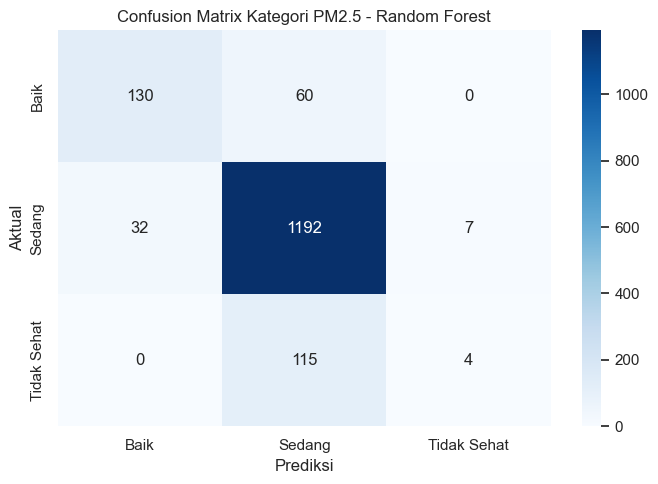

In [15]:
labels = ['Baik', 'Sedang', 'Tidak Sehat']
cm = confusion_matrix(prediksi_test[TARGET_CAT], prediksi_test['kategori_prediksi'], labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix Kategori PM2.5 - Random Forest')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_kategori_pm25.png', dpi=150, bbox_inches='tight')
plt.show()

## Analisis Error per Station dan Waktu

,station,n,MAE,RMSE,Bias_mean_residual,Aktual_mean,Prediksi_mean
0,kelapa gading,220.0,8.0439,10.7209,0.2030,77.6597,77.4567
1,us embassy 1,220.0,8.3127,10.9672,-1.5606,73.0854,74.6460
2,jagakarsa,220.0,8.1488,11.4686,-0.9802,74.6339,75.6141
3,bundaran hi,220.0,8.3125,11.6053,-1.2851,74.1155,75.4006
4,us embassy 2,220.0,9.1388,12.5701,0.2413,78.5342,78.2930
5,kebun jeruk,220.0,9.6366,13.6256,1.3838,78.4234,77.0396
6,lubang buaya,220.0,10.2194,13.7375,-3.7301,70.6051,74.3352


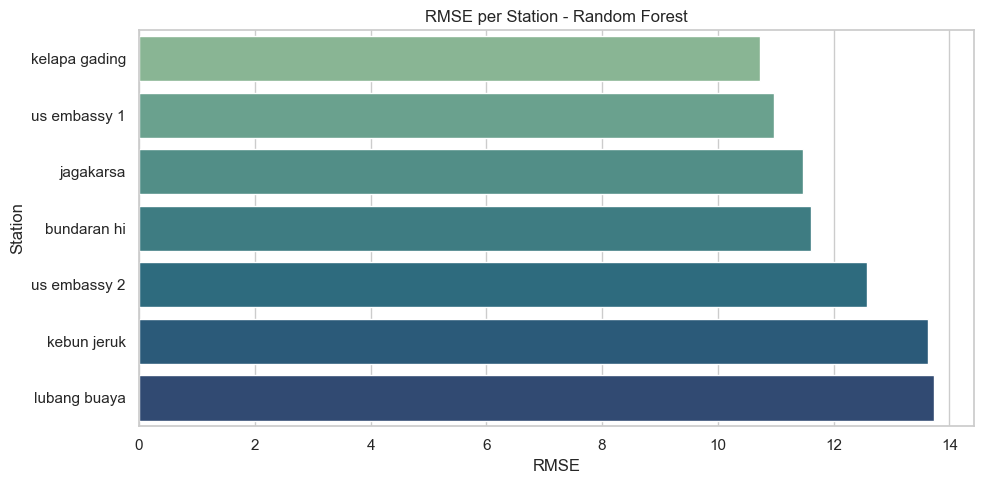

In [16]:
station_error = (
    prediksi_test
    .groupby('station')
    .apply(lambda data: pd.Series({
        'n': len(data),
        'MAE': mean_absolute_error(data[TARGET_REG], data['prediksi_pm25']),
        'RMSE': mean_squared_error(data[TARGET_REG], data['prediksi_pm25']) ** 0.5,
        'Bias_mean_residual': data['residual'].mean(),
        'Aktual_mean': data[TARGET_REG].mean(),
        'Prediksi_mean': data['prediksi_pm25'].mean(),
    }))
    .sort_values('RMSE')
    .reset_index()
)

station_error_display = station_error.copy()
for col in ['MAE', 'RMSE', 'Bias_mean_residual', 'Aktual_mean', 'Prediksi_mean']:
    station_error_display[col] = station_error_display[col].round(4)

display(station_error_display)
station_error_display.to_csv(OUTPUT_DIR / 'error_per_station_random_forest.csv', index=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=station_error_display, x='RMSE', y='station', palette='crest')
plt.title('RMSE per Station - Random Forest')
plt.xlabel('RMSE')
plt.ylabel('Station')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'error_per_station_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()

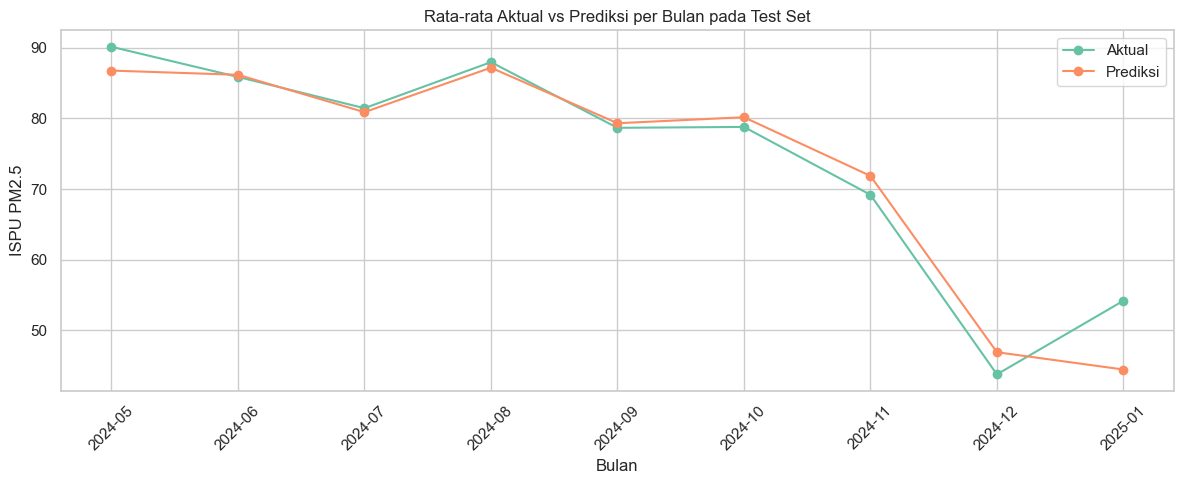

,bulan_test,aktual_mean,prediksi_mean,mae
0,2024-05,90.1019,86.7389,8.3915
1,2024-06,85.8428,86.1432,8.6711
2,2024-07,81.4211,80.8616,8.2588
3,2024-08,87.9315,87.1483,8.1428
4,2024-09,78.6492,79.2972,7.4541
5,2024-10,78.7750,80.1465,8.7400
6,2024-11,69.1839,71.8536,11.6442
7,2024-12,43.7973,46.9300,8.9276
8,2025-01,54.2023,44.4838,11.5069


In [17]:
monthly_eval = prediksi_test.copy()
monthly_eval['bulan_test'] = monthly_eval['tanggal'].dt.to_period('M').astype(str)
monthly_summary = (
    monthly_eval
    .groupby('bulan_test')
    .agg(
        aktual_mean=(TARGET_REG, 'mean'),
        prediksi_mean=('prediksi_pm25', 'mean'),
        mae=('abs_error', 'mean'),
    )
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_summary['bulan_test'], monthly_summary['aktual_mean'], marker='o', label='Aktual')
plt.plot(monthly_summary['bulan_test'], monthly_summary['prediksi_mean'], marker='o', label='Prediksi')
plt.xticks(rotation=45)
plt.title('Rata-rata Aktual vs Prediksi per Bulan pada Test Set')
plt.xlabel('Bulan')
plt.ylabel('ISPU PM2.5')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tren_prediksi_bulanan_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()

display(monthly_summary.round(4))
monthly_summary.to_csv(OUTPUT_DIR / 'tren_prediksi_bulanan_random_forest.csv', index=False)

## Feature Importance Random Forest

,feature,importance
0,pm25_lag_1,0.469544
1,pm25_roll_3_mean,0.130637
2,pm25_roll_7_mean,0.047979
3,pm25_roll_14_mean,0.033753
4,visibility,0.031086
5,windgust,0.028822
6,solarenergy,0.026478
7,humidity,0.024983
8,temp,0.022289
9,pm25_lag_14,0.021802


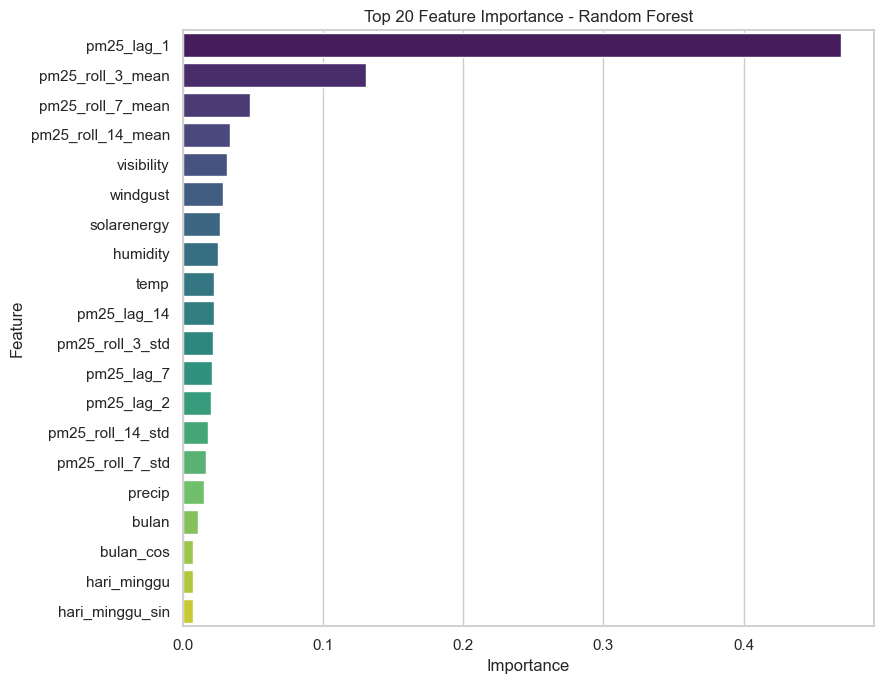

In [18]:
rf_model_step = rf_tuned.named_steps['model']
importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf_model_step.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

importance_display = importance_df.copy()
importance_display['importance'] = importance_display['importance'].round(6)

display(importance_display.head(20))
importance_display.to_csv(OUTPUT_DIR / 'feature_importance_pm25.csv', index=False)

plt.figure(figsize=(9, 7))
sns.barplot(data=importance_display.head(20), x='importance', y='feature', palette='viridis')
plt.title('Top 20 Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance_pm25.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
final_rf_model = clone(rf_tuned)
X_all = df_model[FEATURES]
y_all = df_model[TARGET_REG]
final_rf_model.fit(X_all, y_all)

model_path = OUTPUT_DIR / 'model_pm25_best.pkl'
rf_model_path = OUTPUT_DIR / 'model_pm25_random_forest.pkl'
metadata_path = OUTPUT_DIR / 'model_pm25_metadata.json'

joblib.dump(final_rf_model, model_path)
joblib.dump(final_rf_model, rf_model_path)

metadata = {
    'model_name': 'Random Forest Regression',
    'proposal_model': 'Random Forest Regression',
    'target': TARGET_REG,
    'features': FEATURES,
    'data_path': str(DATA_PATH),
    'validation_start': str(validation_start.date()),
    'test_start': str(test_start.date()),
    'train_core_rows': int(train_core_mask.sum()),
    'validation_rows': int(validation_mask.sum()),
    'train_full_rows': int(train_full_mask.sum()),
    'test_rows': int(test_mask.sum()),
    'best_validation_config': str(best_tuning_row['config']),
    'final_random_forest_params': best_rf_params,
    'oob_r2_train_full_model': float(oob_score),
    'metrics_regression_test': {key: float(value) for key, value in rf_tuned_metrics.items()},
    'metrics_category_from_regression_test': {key: float(value) for key, value in category_eval.items()},
}

metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

print('Model final:', model_path)
print('Model Random Forest :', rf_model_path)
print('Metadata:', metadata_path)
print('Prediksi test:', OUTPUT_DIR / 'prediksi_test_pm25.csv')
print('Ringkasan model:', OUTPUT_DIR / 'hasil_model_regresi.csv')
print('Hasil tuning:', OUTPUT_DIR / 'hasil_tuning_random_forest.csv')

Model final: c:\Users\User\Air Pollution - Daming Project\notebooks\outputs\model_pm25_best.pkl
Model Random Forest : c:\Users\User\Air Pollution - Daming Project\notebooks\outputs\model_pm25_random_forest.pkl
Metadata: c:\Users\User\Air Pollution - Daming Project\notebooks\outputs\model_pm25_metadata.json
Prediksi test: c:\Users\User\Air Pollution - Daming Project\notebooks\outputs\prediksi_test_pm25.csv
Ringkasan model: c:\Users\User\Air Pollution - Daming Project\notebooks\outputs\hasil_model_regresi.csv
Hasil tuning: c:\Users\User\Air Pollution - Daming Project\notebooks\outputs\hasil_tuning_random_forest.csv
